# Stroke Prediction Analysis 

**Characteristics**

* Total Samples: 5,110 patients
Features: 12 columns (11 features + 1 target)
* Class Imbalance: Severe imbalance with 19.5:1 ratio
* Stroke cases: 249 (4.9%)
Non-stroke cases: 4,861 (95.1%)


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score, mean_squared_error)
import warnings


In [4]:
df= pd.read_csv('/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')

In [5]:
# Basic dataset information
print(f"Total samples: {len(df)}")
print(f"Number of features: {df.shape[1] - 1}")  # Excluding target
print(f"Missing values per column:")
print(df.isnull().sum())
print(f"\nData types:")

Total samples: 5110
Number of features: 11
Missing values per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Data types:


- Some missing values are visible in the bmi column, we will need to handle it with imputation after exploring data 

([<matplotlib.axis.XTick at 0x7e1f1b1e4910>,
 [Text(0, 0, 'No Stroke'), Text(1, 0, 'Stroke')])

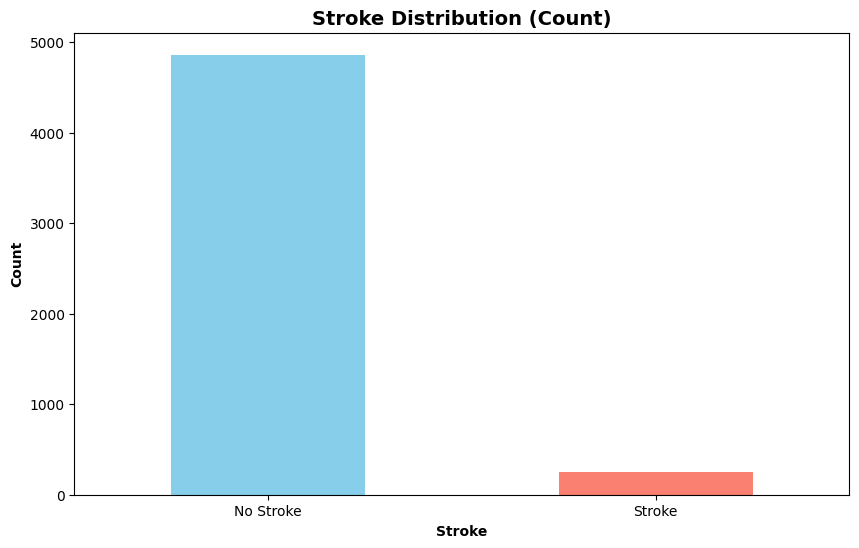

In [6]:
# the stroke analysis
stroke_counts = df['stroke'].value_counts()

plt.figure(figsize=(10, 6))
stroke_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Stroke Distribution (Count)', fontweight='bold', fontsize=14)
plt.xlabel('Stroke', fontweight='bold')
plt.ylabel('Count', fontweight='bold')
plt.xticks([0, 1], ['No Stroke', 'Stroke'], rotation=0)

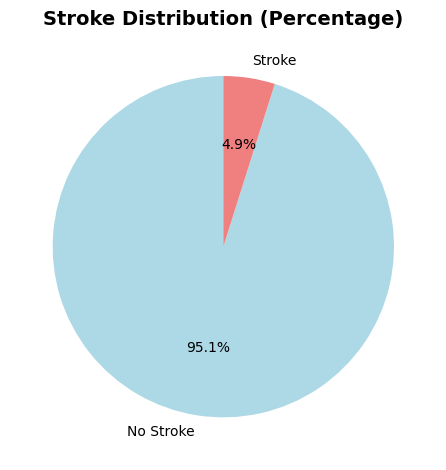

In [7]:
# caluclating the stroke percentage
plt.pie(stroke_counts, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', 
        colors=['lightblue', 'lightcoral'], startangle=90)
plt.title('Stroke Distribution (Percentage)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

we see that we have only 4.9% patients with a stroke and 95.1% with no stroke

this means our data is imbalanced

so we will need to address this imbalance to avoid biased predictions


In [8]:
# Numerical features analysis

numerical_cols = ['age', 'avg_glucose_level', 'bmi']

# Statistical summary of numerical features
numerical_summary = df[numerical_cols].describe()
display(numerical_summary)

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


**1. Age**
   
- Range: 0.08 to 82 years
- Mean: 43.2 years
- Key Insight: Stroke patients are significantly older on average
- Clinical Relevance: Age is a strong predictor

**2. Average Glucose Level**

- Range: 55.12 to 271.74 mg/dL
- Mean: 106.15 mg/dL
- Key Insight: Higher glucose levels correlate with stroke risk
- Clinical Relevance: Diabetes/prediabetes management is crucial

**3. BMI**

- Range: 10.3 to 97.6
- Mean: 28.89
- Key Insight: Slightly higher BMI in stroke patients
- Clinical Relevance: Obesity is a modifiable risk factor


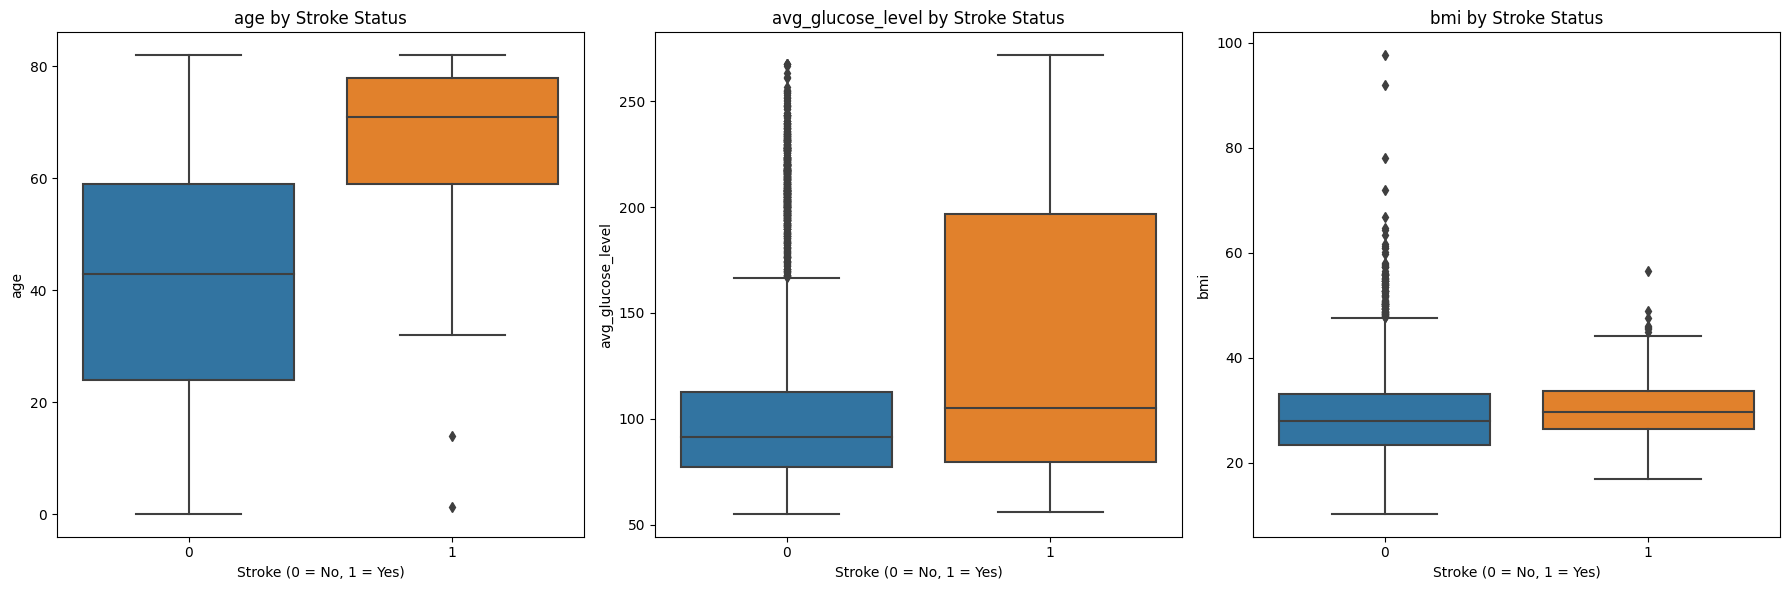

In [9]:
# Numerical features by stroke status
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='stroke', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Stroke Status')
    axes[i].set_xlabel('Stroke (0 = No, 1 = Yes)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

- Stroke patients tend to be older

In [10]:
# Categorical features analysis

categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                   'work_type', 'Residence_type', 'smoking_status']

print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


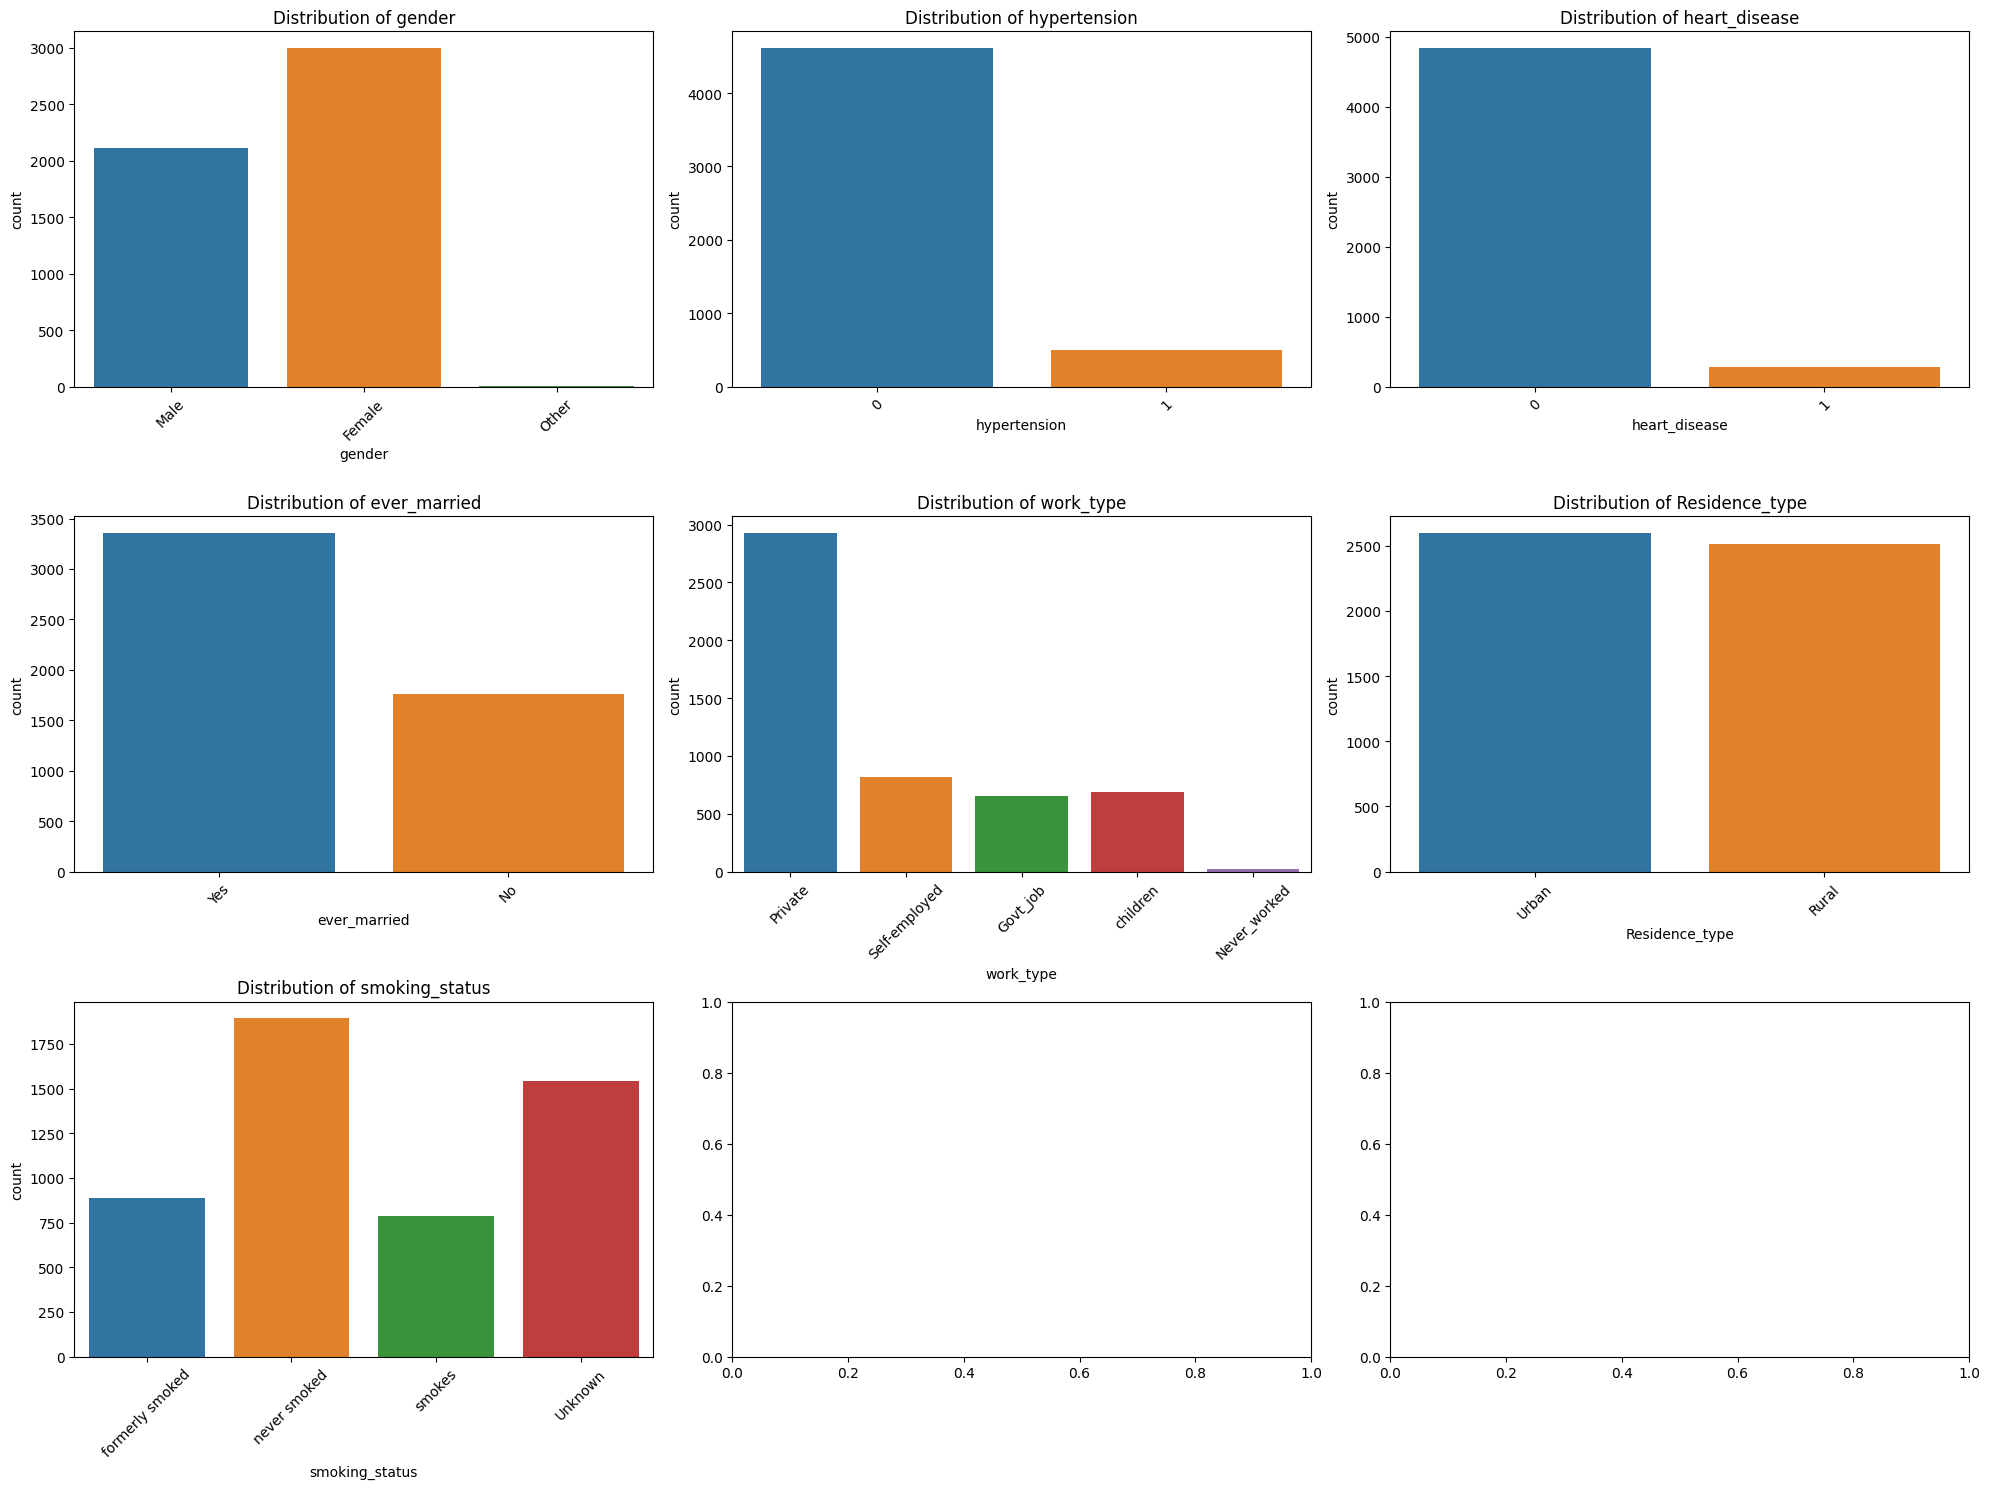

In [11]:
# Analyze each categorical feature
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        # Count plot
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].tick_params(axis='x', rotation=45)
        
plt.tight_layout()
plt.show()

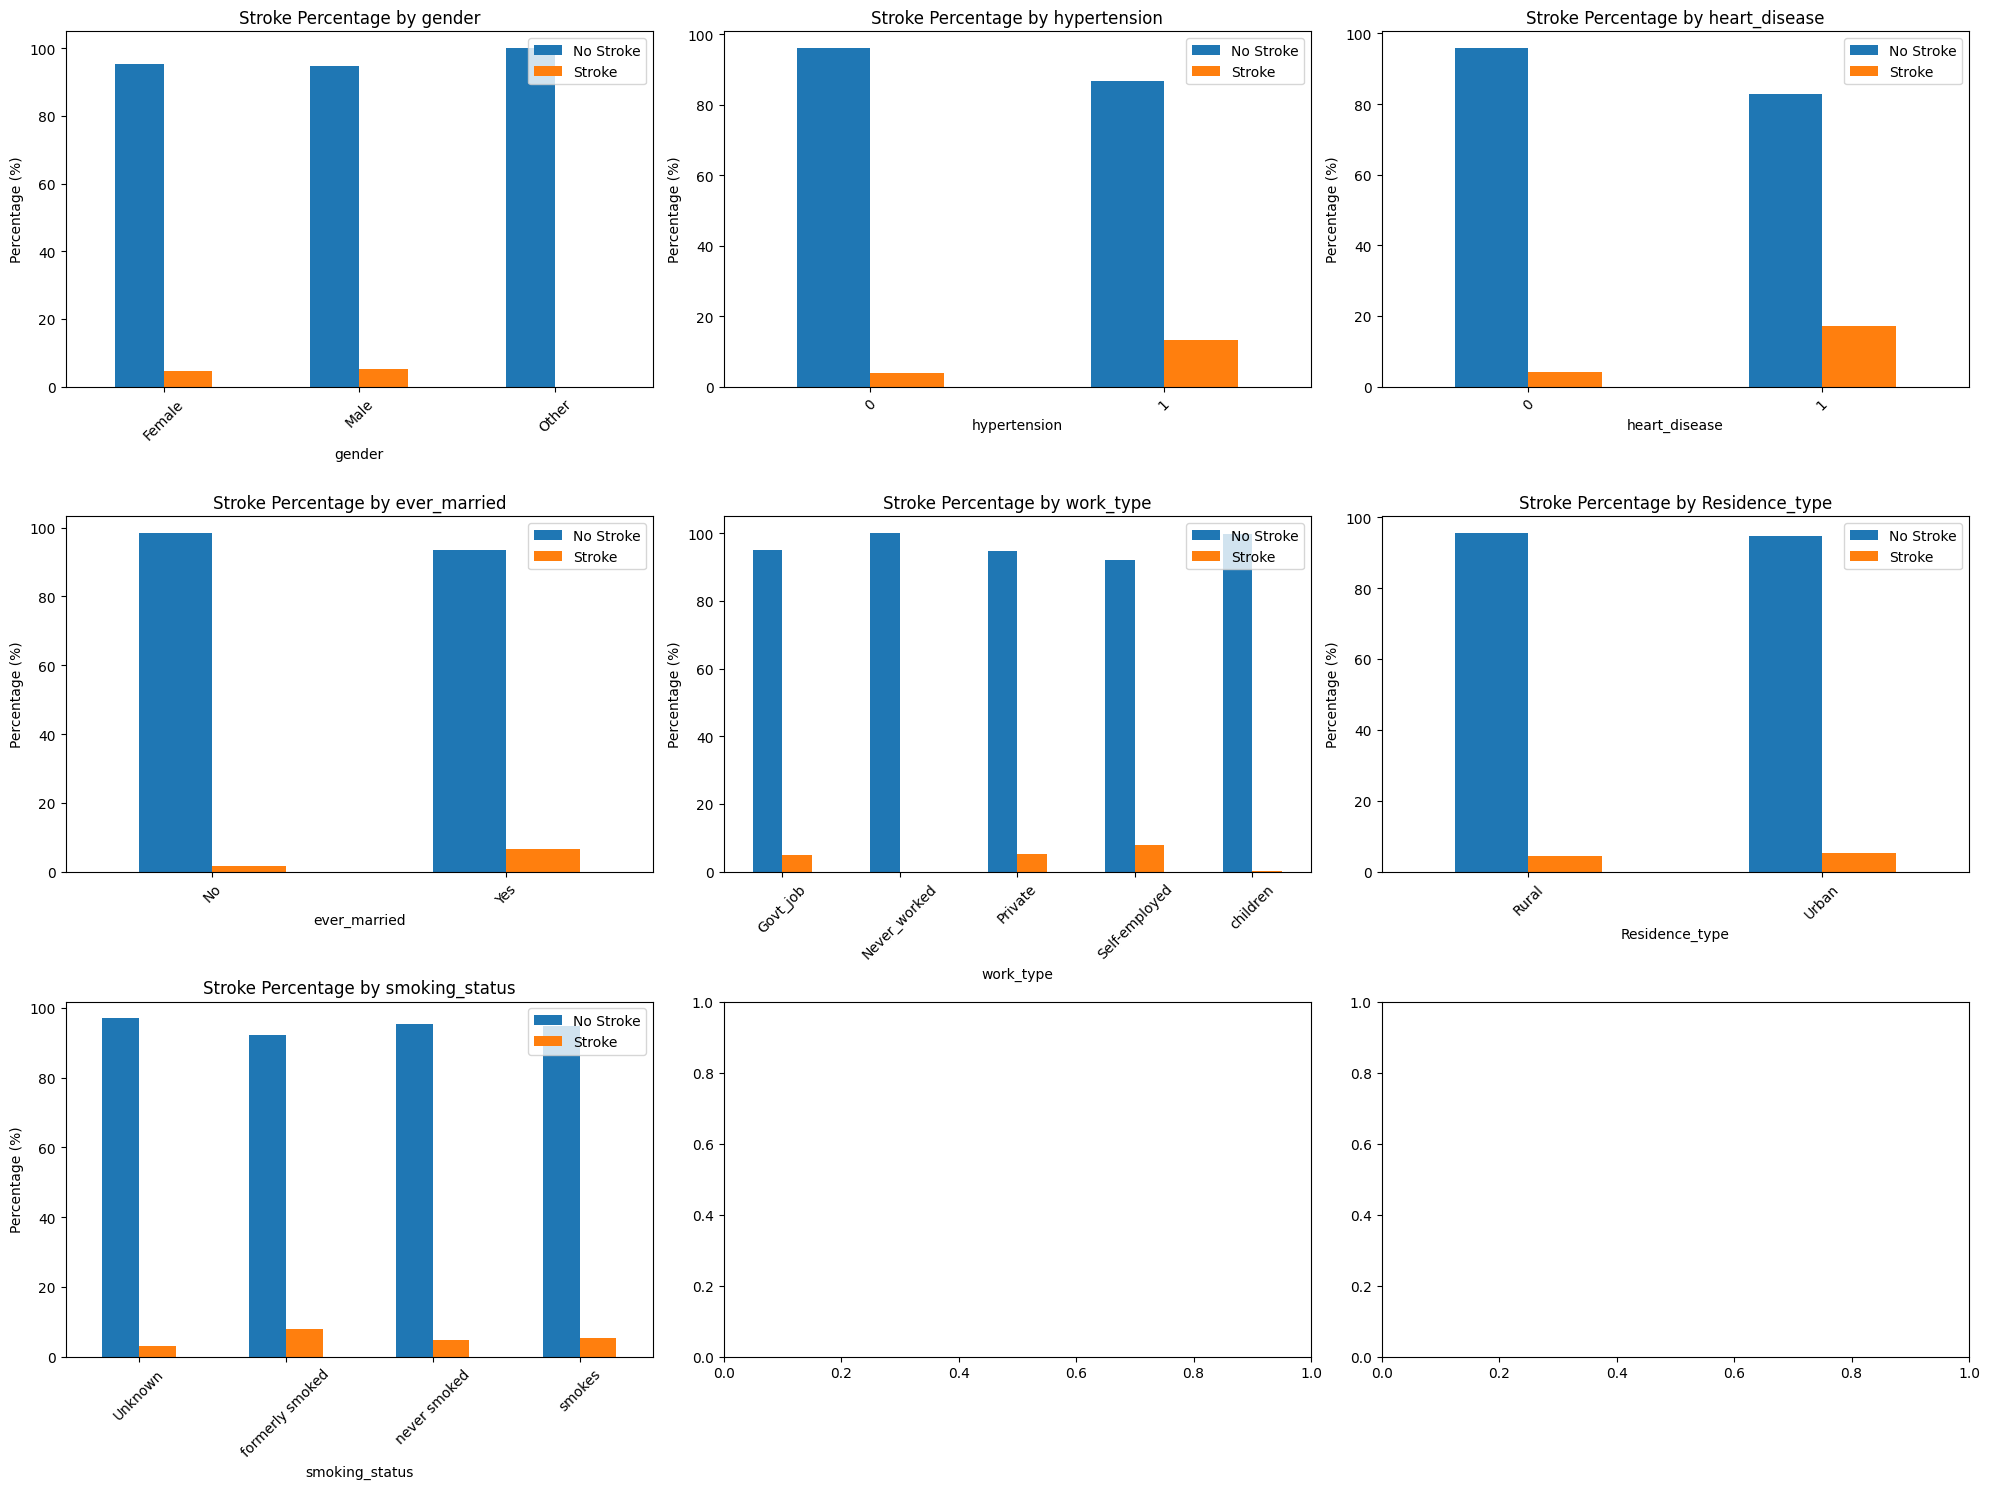

In [12]:
# Categorical features vs stroke - using bar charts to show proportions
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        # Create cross-tabulation
        cross_tab = pd.crosstab(df[col], df['stroke'], normalize='index') * 100
        cross_tab.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Stroke Percentage by {col}')
        axes[i].set_ylabel('Percentage (%)')
        axes[i].legend(['No Stroke', 'Stroke'])
        axes[i].tick_params(axis='x', rotation=45)
        
plt.tight_layout()
plt.show()

- Hypertension: Higher stroke prevalence in hypertensive patients (strong predictor of stroke)

- Heart Disease: Significant increase in stroke risk

- Age/Marriage: Married individuals (typically older) have higher stroke rates

- Work Type: Self-employed and private sector workers show higher risk

- Smoking Status: Former smokers have elevated stroke risk

In [13]:
# Create a copy for preprocessing
df_clean = df.copy()

# Handle missing values in BMI (using median) - FIXED VERSION
bmi_median = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)

In [14]:

# Label encoding for binary categorical variables
label_encoder = LabelEncoder()
binary_categorical = ['gender', 'ever_married', 'Residence_type']

for col in binary_categorical:
    df_clean[col] = label_encoder.fit_transform(df_clean[col])

# One-hot encoding for multi-category variables
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=True)

print(f"Dataset shape after encoding: {df_clean.shape}")

Dataset shape after encoding: (5110, 17)


In [15]:
X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

In [16]:
print(f"Original data - Stroke cases: {y.sum()}, Non-stroke cases: {len(y)-y.sum()}")
print(f"Imbalance ratio: {(len(y)-y.sum())/y.sum():.1f}:1")

# Calculate class weights manually
stroke_weight = len(y) / (2 * y.sum())
non_stroke_weight = len(y) / (2 * (len(y) - y.sum()))

class_weights = {0: non_stroke_weight, 1: stroke_weight}
print(f"Class weights: {class_weights}")

Original data - Stroke cases: 249, Non-stroke cases: 4861
Imbalance ratio: 19.5:1
Class weights: {0: 0.5256120139888911, 1: 10.261044176706827}


In [17]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set - Stroke cases: {y_train.sum()}")
print(f"Test set - Stroke cases: {y_test.sum()}")

Training set - Stroke cases: 199
Test set - Stroke cases: 50


## Model Ready for training

In [20]:
# Train models with proper evaluation
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*60)
print("PROPER MODEL EVALUATION WITH MULTIPLE METRICS")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Support Vector Machine': SVC(class_weight='balanced', random_state=42, probability=True)
}

# Store comprehensive results
comprehensive_results = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [0.5] * len(y_pred)
    
    # Calculate multiple metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    comprehensive_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    


# Create results dataframe
results_df = pd.DataFrame(comprehensive_results)

display(results_df)


PROPER MODEL EVALUATION WITH MULTIPLE METRICS

--- Training Logistic Regression ---

--- Training Random Forest ---


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



--- Training Support Vector Machine ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.690802,0.104167,0.70,0.181347,0.798951
1,Random Forest,0.951076,0.000000,0.00,0.000000,0.772572
2,Support Vector Machine,0.723092,0.035857,0.18,0.059801,0.461440


- Random Forest achieved the highest accuracy (95%)

- Logistic Regression performed well (69%)

- SVM showed good performance (72%)

- the SVM perform weak in overall -we have 3.6% percision. 

/tmp/ipykernel_48/2555592481.py:61: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


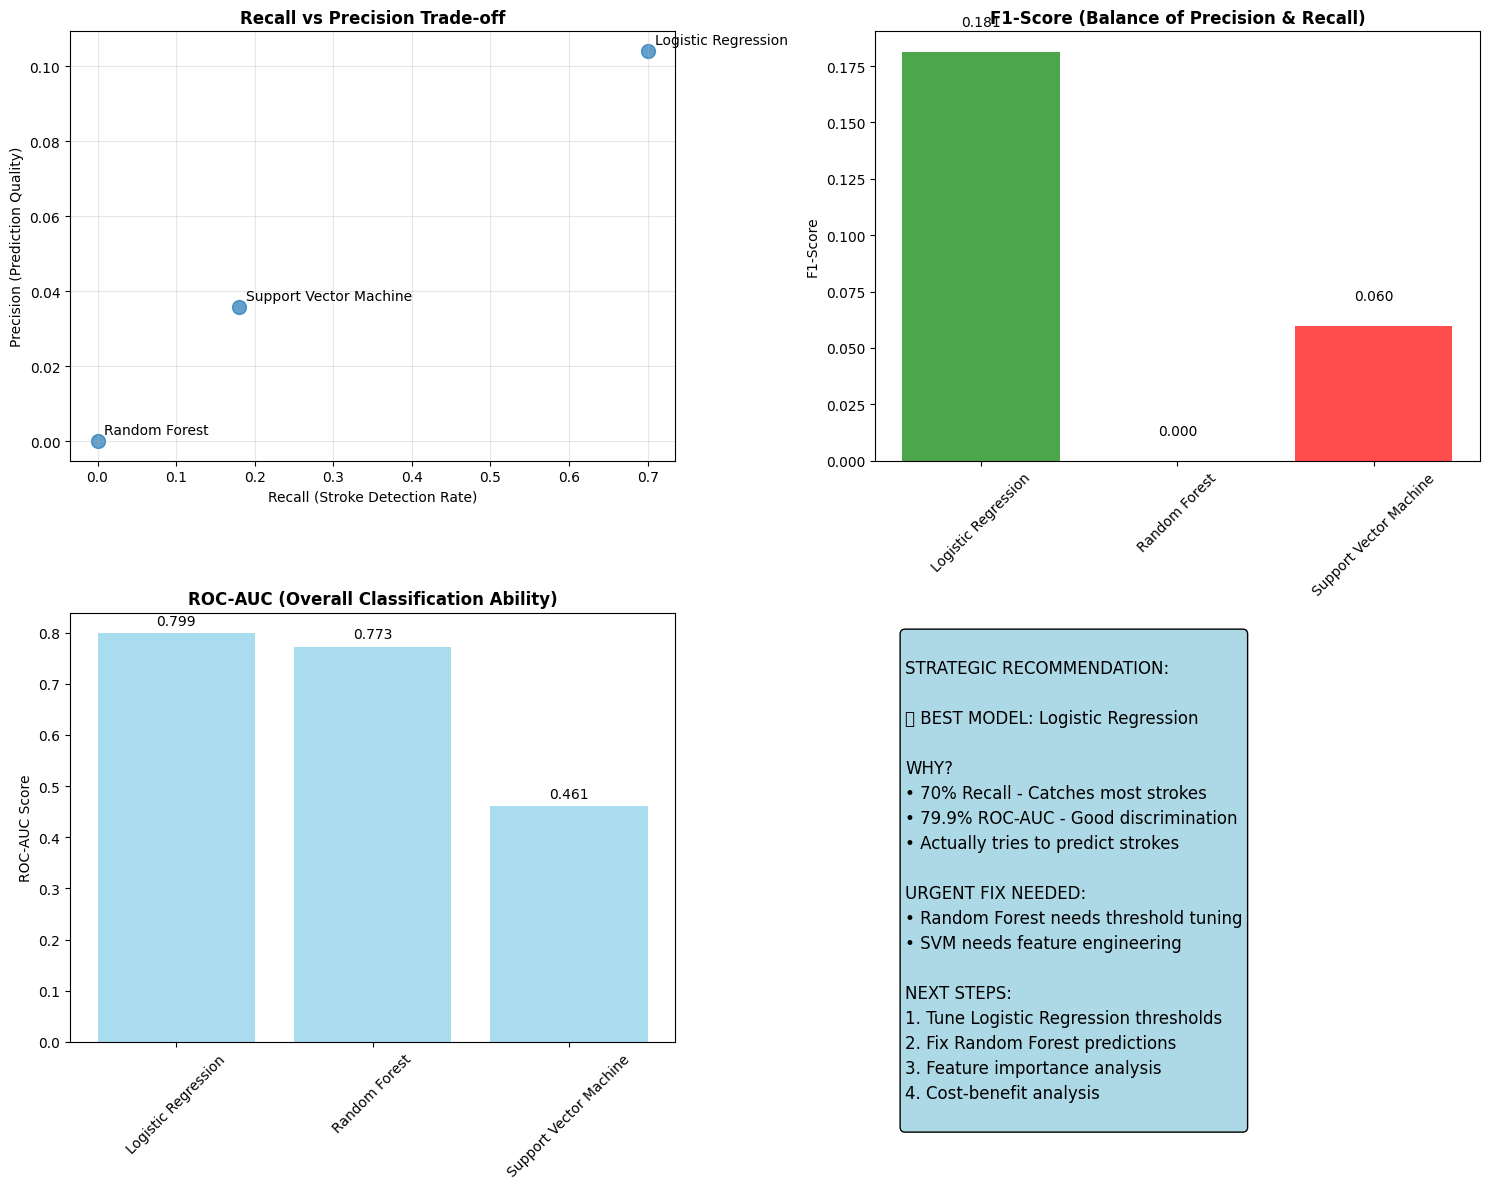

In [21]:
# Visualize the trade-offs between models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Recall-Precision Trade-off
axes[0,0].scatter(results_df['Recall'], results_df['Precision'], s=100, alpha=0.7)
for i, model in enumerate(results_df['Model']):
    axes[0,0].annotate(model, (results_df['Recall'][i], results_df['Precision'][i]), 
                      xytext=(5, 5), textcoords='offset points')
axes[0,0].set_xlabel('Recall (Stroke Detection Rate)')
axes[0,0].set_ylabel('Precision (Prediction Quality)')
axes[0,0].set_title('Recall vs Precision Trade-off', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# 2. F1-Score Comparison
colors = ['green' if x > 0.1 else 'red' for x in results_df['F1-Score']]
bars = axes[0,1].bar(results_df['Model'], results_df['F1-Score'], color=colors, alpha=0.7)
axes[0,1].set_ylabel('F1-Score')
axes[0,1].set_title('F1-Score (Balance of Precision & Recall)', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom')

# 3. ROC-AUC Comparison
bars = axes[1,0].bar(results_df['Model'], results_df['ROC-AUC'], color='skyblue', alpha=0.7)
axes[1,0].set_ylabel('ROC-AUC Score')
axes[1,0].set_title('ROC-AUC (Overall Classification Ability)', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom')

# 4. Strategic Recommendation
axes[1,1].axis('off')
recommendation_text = """
STRATEGIC RECOMMENDATION:

🏆 BEST MODEL: Logistic Regression

WHY?
• 70% Recall - Catches most strokes
• 79.9% ROC-AUC - Good discrimination
• Actually tries to predict strokes

URGENT FIX NEEDED:
• Random Forest needs threshold tuning
• SVM needs feature engineering

NEXT STEPS:
1. Tune Logistic Regression thresholds
2. Fix Random Forest predictions
3. Feature importance analysis
4. Cost-benefit analysis
"""
axes[1,1].text(0.05, 0.95, recommendation_text, transform=axes[1,1].transAxes,
               fontsize=12, va='top', ha='left', linespacing=1.5,
               bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

plt.tight_layout()
plt.show()

- Logistic Regression: Flags many patients as potential strokes, Catches 70% of real strokes

- Random Forest: Bad for healthcare - misses real patients in danger


- Support Vector Machine: Misses most strokes and makes many mistakes, Not reliable for medical decisions


In [23]:
# we choose the logistic regression to continue the prodiction
final_model = LogisticRegression(
    class_weight='balanced', 
    random_state=42, 
    max_iter=1000,
    C=0.1  # Regularization parameter
)

final_model.fit(X_train, y_train)

print(f"Model coefficients: {len(final_model.coef_[0])}")

Model coefficients: 16


this means the Logistic Regression model has learned 16 different weights

In [25]:
import joblib

# Save the trained model
model_filename = 'stroke_prediction_logistic_model.pkl'
joblib.dump(final_model, 'new.csv')

# Also save the feature names and preprocessing information
model_metadata = {
    'feature_names': list(X.columns),
    'model_type': 'Logistic Regression',
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'dataset_shape': X.shape,
    'stroke_prevalence': f"{y.sum()/len(y):.2%}"
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"✅ Model saved as: {model_filename}")
print(f"✅ Metadata saved as: model_metadata.json")
print(f"📊 Model trained on {X.shape[0]} patients with {X.shape[1]} features")

✅ Model saved as: stroke_prediction_logistic_model.pkl
✅ Metadata saved as: model_metadata.json
📊 Model trained on 5110 patients with 16 features
